# Covering factor per ogni linea e per ogni blazar e poi stima della LBLR
In questo notebook:
1) calcolo il covering factor di ogni linea  
2) calcolo la luminosità della BLR di ciascun blazar pesando le righe secondo Vanden Berk


## 1) Calcolo del covering factor:  
- leggo le masse dei buchi neri da `masse.csv`
- leggo le transizioni da `dati.asc`
- leggo le luminosità di riga da `Tab_completa_revisione.csv` --> L_line
- costruisco per ogni blazar lo spettro del disco
- calcolo le luminosità di ionizzazione L_ion
- confronto L_line con L_ion
- calcolo il rapporto: Cf= L_line/L_ion  per ogni linea osservata di ogni blazar

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Costanti fisiche in cgs
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

# Parametri del modello
eta = 0.083

Nr = 2000
Nnu = 400
nu_min = 1e13
nu_max = 1e17

# File input
file_masse = "masse.csv"
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

In [19]:
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None

In [20]:
def costruisci_spettro_disco(MBH_solar, eta=0.083,Nr=2000, Nnu=400, nu_min=1e13, nu_max=1e17):
    """
    Costruisce lo spettro del disco per una massa MBH_solar [Msun].
    Restituisce nu, Lnu, nuLnu e un dizionario con i parametri fisici principali.
    """
    MBH = MBH_solar * Msun   #MBH_solar è in funzione della massa del sole

    Ledd = 1.3e38 * MBH_solar
    Ldisk = 0.1* Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs

    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))

    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = {
        "MBH_solar": MBH_solar,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot": Mdot,
        "Rs": Rs,
        "Rin": Rin,
        "Rout": Rout
    }

    return nu, Lnu, nuLnu, info

In [21]:
def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
    nome_transizione   E_ion   nu_ion
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=('U50', float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })

In [22]:
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e17):
    """
    Calcola L_ion = integral_{nu_ion}^{nu_max} Lnu dnu
    per ogni transizione.
    """
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)

In [23]:
def estrai_linee_osservate(row, norm_columns):
    """
    Estrae le linee osservate positive da una riga del dataframe.
    """
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line
        })

    return pd.DataFrame(risultati)

In [24]:
def fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar):
    plt.figure(figsize=(8, 6))
    plt.loglog(nu, Lnu, color="black", lw=2, label=r"$L_\nu$ disco")

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % cmap.N) for i in range(len(df_lion))]

    for (_, row), col in zip(df_lion.iterrows(), colors):
        plt.axvline(row["nu_ion"], color=col, lw=1.4, alpha=0.8, label=row["line_name"])

    plt.xlabel(r"$\nu$ [Hz]")
    plt.ylabel(r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]")
    plt.title(f"Spettro del disco - {nome_blazar}")
    plt.xlim(nu.min(), nu.max())
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

In [25]:
# Lettura dei file

df_masse = pd.read_csv(file_masse)
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)

#print("Colonne in masse.csv:")
#print(df_masse.columns.tolist())

#print("\nColonne in Tab_completa_revisione.csv:")
#print(df_tab.columns.tolist())

In [26]:
# Identificazione delle colonne utili

col_name_masse = trova_colonna(df_masse, ["label", "name", "nome", "blazar", "source"])
col_mass = trova_colonna(df_masse, ["MBH", "Mbh", "mass", "massa", "logMBH"], obbligatoria=True)
col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")] 

In [27]:
# Preparazione delle masse

# MBH è già in Msun
df_masse["MBH_solar"] = pd.to_numeric(df_masse[col_mass], errors="coerce")
# preparo tabella finale
df_masse_use = df_masse[[col_name_masse, "MBH_solar"]].copy()
df_masse_use = df_masse_use.rename(columns={col_name_masse: "label"})

# Merge tra masse e linee osservate
df_tab_use = df_tab.rename(columns={col_name_tab: "label"}).copy()
df_all = df_tab_use.merge(df_masse_use, on="label", how="inner")

#print(f"Blazar in comune trovati: {len(df_all)}")
#display(df_all[["label", "MBH_solar"]])

Blazar: J1745.6
redshift = 0.078
MBH = 3.200e+08 Msun
Ledd  = 4.160e+46 erg/s
Ldisk = 4.160e+45 erg/s
Mdot  = 5.577e+25 g/s

Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,Ha,3.631777e+42,3.832174e+45,0.000948
1,Hb,1.103068e+42,3.677675e+45,0.000300


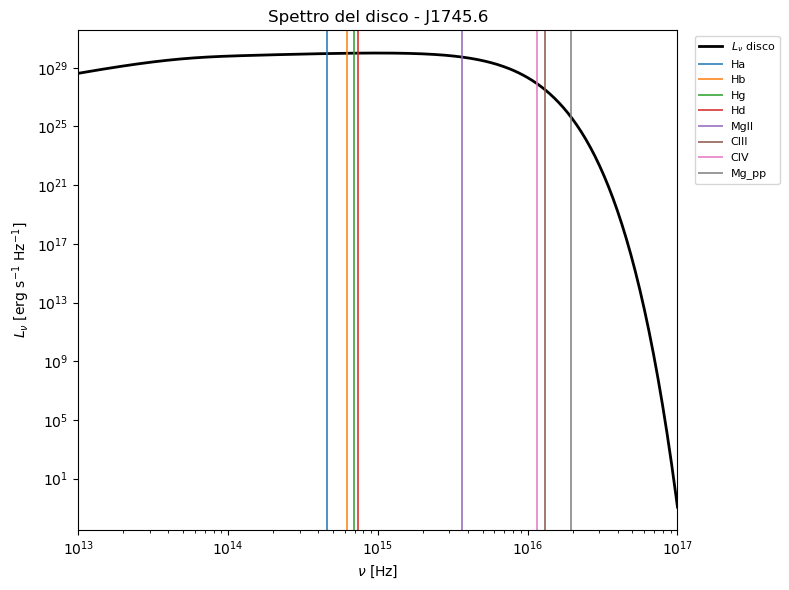

In [28]:
# ANALISI DI UN SINGOLO BLAZAR 

def analizza_blazar(row, df_trans, norm_columns, mostra_grafico=True):
    nome_blazar = row["label"]
    MBH_solar = row["MBH_solar"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    print("=" * 80)
    print(f"Blazar: {nome_blazar}")
    print(f"redshift = {redshift}")
    print(f"MBH = {MBH_solar:.3e} Msun")

    # spettro disco
    nu, Lnu, nuLnu, info = costruisci_spettro_disco(MBH_solar=MBH_solar,eta=eta,Nr=Nr,Nnu=Nnu,nu_min=nu_min,nu_max=nu_max)

    print(f"Ledd  = {info['Ledd']:.3e} erg/s")
    print(f"Ldisk = {info['Ldisk']:.3e} erg/s")
    print(f"Mdot  = {info['Mdot']:.3e} g/s")

    # L_ion teoriche
    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)

    # linee osservate
    df_linee = estrai_linee_osservate(row, norm_columns)


    # merge e covering factor
    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[(df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0), "covering_factor"] = np.nan

    print("\nConfronto finale per ogni linea:")
    display(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    if mostra_grafico:
        fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar)
    return df_conf


indice_blazar = 0   # cambio questo numero per scegliere il blazar
row = df_all.iloc[indice_blazar]
df_risultato_singolo = analizza_blazar(row, df_trans, norm_columns, mostra_grafico=True)

In [29]:
# Analisi di tutti i blazar
tutti_risultati = []

for i in range(len(df_all)):
    row = df_all.iloc[i]
    df_conf = analizza_blazar(row, df_trans, norm_columns, mostra_grafico=False)
    df_conf["label"] = row["label"]
    tutti_risultati.append(df_conf)

Blazar: J1745.6
redshift = 0.078
MBH = 3.200e+08 Msun
Ledd  = 4.160e+46 erg/s
Ldisk = 4.160e+45 erg/s
Mdot  = 5.577e+25 g/s

Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,Ha,3.631777e+42,3.832174e+45,0.000948
1,Hb,1.103068e+42,3.677675e+45,0.000300


Blazar: J0021.6-6835
redshift = 0.354
MBH = 6.500e+08 Msun
Ledd  = 8.450e+46 erg/s
Ldisk = 8.450e+45 erg/s
Mdot  = 1.133e+26 g/s

Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,Hb,6.569277e+42,7.227998e+45,0.000909
1,Hg,1.867612e+42,7.042926e+45,0.000265
2,Hd,1.343418e+42,6.920494e+45,0.000194


Blazar: J0050.0-4458
redshift = 0.121
MBH = 2.800e+08 Msun
Ledd  = 3.640e+46 erg/s
Ldisk = 3.640e+45 erg/s
Mdot  = 4.880e+25 g/s

Confronto finale per ogni linea:


...

,line_name,L_line,L_ion,covering_factor
0,MgII,5.462299e+43,1.685095e+45,0.032415
1,Hg,1.217875e+43,7.347750e+45,0.001657
2,Hd,4.159905e+43,7.218149e+45,0.005763


Blazar: J0133.2-5159
redshift = 0.925
MBH = 8.700e+08 Msun
Ledd  = 1.131e+47 erg/s
Ldisk = 1.131e+46 erg/s
Mdot  = 1.516e+26 g/s

Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,MgII,7.153948e+43,1.873048e+45,0.038194
1,Hd,1.829014e+43,9.077187e+45,0.002015


Blazar: J170108.89
redshift = 1.895
MBH = 1.600e+09 Msun
Ledd  = 2.080e+47 erg/s
Ldisk = 2.080e+46 erg/s
Mdot  = 2.788e+26 g/s

Confronto finale per ogni linea:


,line_name,L_line,L_ion,covering_factor
0,MgII,2.115836e+41,2.307134e+45,0.000092
1,CIV,9.878503e+40,1.268076e+42,0.077902
2,CIII,4.863144e+41,2.098327e+41,2.317629


In [30]:
# Tabella finale con tutti i covering factor di tutte le linee e di tutti i blazar
df_risultati_finali = pd.concat(tutti_risultati, ignore_index=True)

print("Tabella finale completa:")
display(df_risultati_finali[["label", "line_name", "L_line", "L_ion", "covering_factor"]])


Tabella finale completa:


,label,line_name,L_line,L_ion,covering_factor
0,J1745.6,Ha,3.631777e+42,3.832174e+45,0.000948
1,J1745.6,Hb,1.103068e+42,3.677675e+45,0.000300
2,J0021.6-6835,Hb,6.569277e+42,7.227998e+45,0.000909
3,J0021.6-6835,Hg,1.867612e+42,7.042926e+45,0.000265
4,J0021.6-6835,Hd,1.343418e+42,6.920494e+45,0.000194
5,J0050.0-4458,Ha,3.335316e+41,3.365465e+45,0.000099
6,J0050.0-4458,Hb,6.686534e+40,3.235416e+45,0.000021
7,J0050.0-4458,Hg,5.502976e+40,3.172187e+45,0.000017
8,J0050.0-4458,Hd,1.004694e+40,3.130148e+45,0.000003
9,J0508.2-1936,CIV,4.174072e+44,1.439934e+42,289.879394


In [31]:
# tengo solo le colonne che mi servono
df_cf_tabella = df_risultati_finali[["label", "line_name", "covering_factor"]].copy()

# costruisco la tabella larga: righe = blazar, colonne = linee
tabella_cf = df_cf_tabella.pivot(index="label", columns="line_name", values="covering_factor")

# ordino le colonne per nome
tabella_cf = tabella_cf.reindex(sorted(tabella_cf.columns), axis=1)

# metto il nome del blazar come prima colonna normale
tabella_cf = tabella_cf.reset_index()

# sostituisco i valori mancanti con "-"
tabella_cf = tabella_cf.fillna("-")

print("Tabella finale dei covering factor:")
display(tabella_cf)

Tabella finale dei covering factor:


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.000909,0.000194,0.000265,-
1,J0050.0-4458,-,-,0.000099,0.000021,0.000003,0.000017,-
2,J0059.1-5701,-,-,-,-,0.002435,0.005341,0.03018
3,J0133.2-5159,-,-,-,-,0.002015,-,0.038194
4,J0508.2-1936,285.734423,289.879394,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.00218,0.003023,0.001143,0.10478
6,J1123.3-2529,-,-,0.000445,0.000905,0.000128,0.000371,-
7,J1329.4-0530,-,-,-,-,0.005763,0.001657,0.032415
8,J152422.56,0.13863,-,-,-,0.00002,-,0.000077
9,J170108.89,2.317629,0.077902,-,-,-,-,0.000092


## 2) Stima della luminosità totale della BLR   : ERRATO, CORRETTO IN CALCOLO_CF_4..

In questa sezione stimo la luminosità totale della Broad Line Region (BLR) per ciascun blazar a partire dalle luminosità delle singole linee di emissione osservate.

Poiché non tutte le linee del BLR sono osservabili per ogni oggetto, utilizzo un template medio di quasar (Vanden Berk et al. 2001), che fornisce i contributi relativi delle principali linee di emissione rispetto al totale della BLR.
Ad ogni linea associo un peso wi, proporzionale al suo contributo medio nel BLR. Il totale dei pesi del template è pari a 199.122.
Definisco quindi la frazione della linea i-esima come: fi = wi / (somma di tutti i pesi del template)
Per ogni blazar considero solo le linee osservate che sono presenti nel template e ne sommo le luminosità:
L_line_sum = somma delle luminosità delle linee osservate
Sommo inoltre le corrispondenti frazioni: f_sum = somma delle frazioni fi delle linee osservate
Stimo quindi la luminosità totale della BLR come: L_BLR = L_line_sum / f_sum

In [32]:
# Pesi BLR dal template di Vanden Berk 2001
# colonna: Rel. Flux [100 x F / F(Lyalpha)]
# NOTA: "CIII" qui è intesa come C III] 

BLR_WEIGHTS_VANDENBERK = {
    "CIV": 25.291,
    "CIII": 15.943,
    "MgII": 14.725,
    "Hd": 1.066,
    "Hg": 2.616,
    "Hb": 8.649,
    "Ha": 30.832}

BLR_TOTAL_VANDENBERK = 199.122

In [33]:
# Tengo solo le linee che hanno un peso nel template
df_lblr_linee = df_risultati_finali[["label", "line_name", "L_line"]].copy()
df_lblr_linee["w_i"] = df_lblr_linee["line_name"].map(BLR_WEIGHTS_VANDENBERK)
df_lblr_linee = df_lblr_linee[df_lblr_linee["w_i"].notna()].copy()  # tengo solo le linee che hanno un peso nel template
#print("Linee usate per il calcolo di L_BLR:")
#display(df_lblr_linee)

# Frazione della singola linea rispetto al BLR totale
df_lblr_linee["f_i"] = df_lblr_linee["w_i"] / BLR_TOTAL_VANDENBERK
#print("Tabella con le frazioni del template:")
#display(df_lblr_linee)

In [34]:
# L_BLR totale per ogni blazar: L_BLR = somma(L_linea) / somma(f_i)

df_lblr_finale = (
    df_lblr_linee
    .groupby("label", as_index=False)
    .agg(
        L_line_sum=("L_line", "sum"),
        f_sum=("f_i", "sum"),
        n_linee_BLR=("line_name", "size")))

df_lblr_finale["L_BLR_tot"] = df_lblr_finale["L_line_sum"] / df_lblr_finale["f_sum"]

print("Tabella finale con L_BLR totale per ogni blazar:")
display(df_lblr_finale)

Tabella finale con L_BLR totale per ogni blazar:


,label,L_line_sum,f_sum,n_linee_BLR,L_BLR_tot
0,J0021.6-6835,9.780306e+42,0.061927,3,1.579332e+44
1,J0050.0-4458,4.654736e+41,0.216767,4,2.147349e+42
2,J0059.1-5701,1.153940e+44,0.092441,3,1.248301e+45
3,J0133.2-5159,8.982962e+43,0.079303,2,1.132737e+45
4,J0508.2-1936,4.877605e+44,0.207079,2,2.355431e+45
5,J0922.8-3959,2.596096e+44,0.135876,4,1.910629e+45
6,J1123.3-2529,8.653962e+42,0.216767,4,3.992295e+43
7,J1329.4-0530,1.084008e+44,0.092441,3,1.172651e+45
8,J152422.56,4.486414e+41,0.159370,3,2.815100e+42
9,J170108.89,7.966830e+41,0.281029,3,2.834881e+42
